Imports

In [1]:
import tensorflow as tf
from tensorflow import keras
from keras.models import Sequential
from keras.optimizers import Adam
from keras.layers import Conv2D, MaxPool2D, Flatten, Dense, Dropout, BatchNormalization
import numpy as np
import matplotlib.pyplot as plt
from keras.utils import to_categorical

In [2]:
import sys; from google.colab import drive; drive.mount('/content/drive'); sys.path.append('/content/drive/MyDrive/Colab_Data')
import cifar_loader
(x_train, y_train), (x_test, y_test) = cifar_loader.load_data()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
x_train.shape

(50000, 32, 32, 3)

Normalization

In [4]:
x_train=x_train.astype('float32') / 255.0
x_test=x_test.astype('float32') / 255.0

One hot encoding

In [5]:
y_train= to_categorical(y_train, 10)
y_test= to_categorical(y_test, 10)

Define alexnet model

In [6]:
model = Sequential()
# 1st conv layer
model.add(Conv2D(filters=96, kernel_size=(3, 3), padding='same', activation='relu', input_shape=(32, 32, 3)))
model.add(BatchNormalization())
model.add(MaxPool2D(pool_size=(2, 2)))

# 2nd conv layer
model.add(Conv2D(filters=256, kernel_size=(3, 3), padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPool2D(pool_size=(2, 2)))

# 3rd conv layer
model.add(Conv2D(filters=384, kernel_size=(3, 3), padding='same', activation='relu'))
model.add(BatchNormalization())

# 4th conv layer
model.add(Conv2D(filters=384, kernel_size=(3, 3), padding='same', activation='relu'))
model.add(BatchNormalization())

# 5th conv layer
model.add(Conv2D(filters=256, kernel_size=(3, 3), padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPool2D(pool_size=(2, 2)))

# Flatten and Dense layer
model.add(Flatten())
model.add(Dense(4096, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(4096, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(10, activation='softmax'))

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [7]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 96)     │         2,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 96)     │           384 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 256)    │       221,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 384)      │       885,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 384)      │         1,536 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 8, 8, 384)      │     1,327,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 8, 8, 384)      │         1,536 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 256)      │       884,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │        40,970 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 36,930,826 (140.88 MB)

 Trainable params: 36,928,074 (140.87 MB)

 Non-trainable params: 2,752 (10.75 KB)

In [8]:
# compile the model
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [9]:
# training model=

history= model.fit(x_train, y_train, batch_size=128, epochs=20, validation_split=0.25, verbose=1)

Epoch 1/20
293/293 ━━━━━━━━━━━━━━━━━━━━ 50s 119ms/step - accuracy: 0.3927 - loss: 2.0882 - val_accuracy: 0.1078 - val_loss: 3.4401
Epoch 2/20
293/293 ━━━━━━━━━━━━━━━━━━━━ 56s 66ms/step - accuracy: 0.5502 - loss: 1.2724 - val_accuracy: 0.4358 - val_loss: 1.6003
Epoch 3/20
293/293 ━━━━━━━━━━━━━━━━━━━━ 20s 69ms/step - accuracy: 0.6370 - loss: 1.0581 - val_accuracy: 0.4367 - val_loss: 1.6077
Epoch 4/20
293/293 ━━━━━━━━━━━━━━━━━━━━ 19s 66ms/step - accuracy: 0.6944 - loss: 0.9038 - val_accuracy: 0.6010 - val_loss: 1.1670
Epoch 5/20
293/293 ━━━━━━━━━━━━━━━━━━━━ 19s 65ms/step - accuracy: 0.7349 - loss: 0.7914 - val_accuracy: 0.6372 - val_loss: 1.0667
Epoch 6/20
293/293 ━━━━━━━━━━━━━━━━━━━━ 19s 65ms/step - accuracy: 0.7737 - loss: 0.6849 - val_accuracy: 0.6335 - val_loss: 1.1852
Epoch 7/20
293/293 ━━━━━━━━━━━━━━━━━━━━ 19s 66ms/step - accuracy: 0.8067 - loss: 0.5949 - val_accuracy: 0.6084 - val_loss: 1.1597
Epoch 8/20
293/293 ━━━━━━━━━━━━━━━━━━━━ 19s 66ms/step - accuracy: 0.8315 - loss: 0.5180 -

In [10]:
# evaluate on test set
test_loss, test_acc=model.evaluate(x_test, y_test, verbose=1)
print(f'Test accuracy: {test_acc:.4f}')

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.7870 - loss: 0.8976
Test accuracy: 0.7870


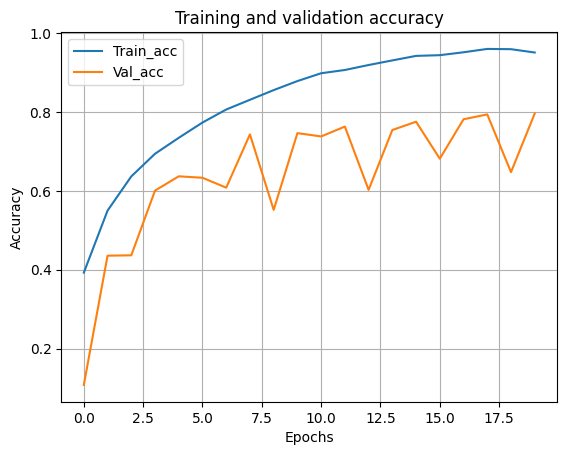

In [12]:
# plot trainning history
plt.plot(history.history['accuracy'], label='Train_acc')
plt.plot(history.history['val_accuracy'], label='Val_acc')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

In [13]:
# sample images
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


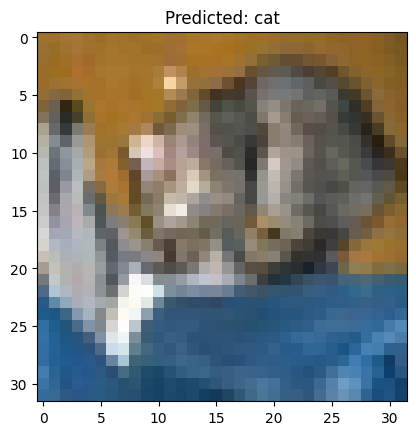

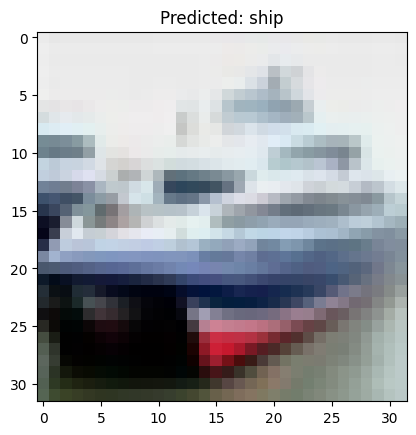

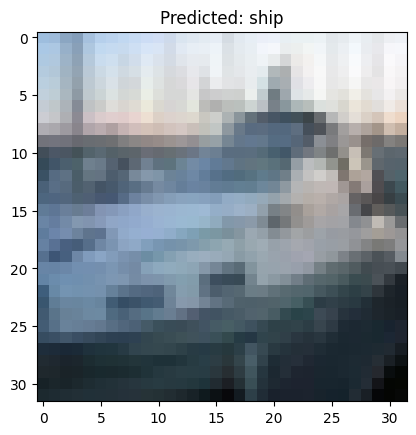

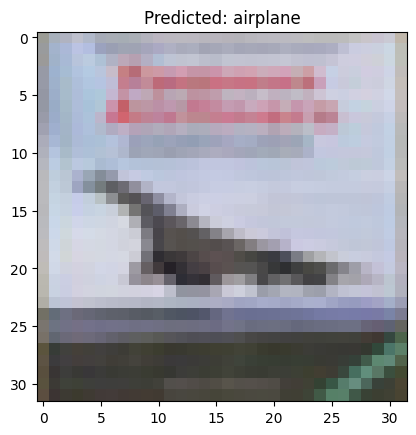

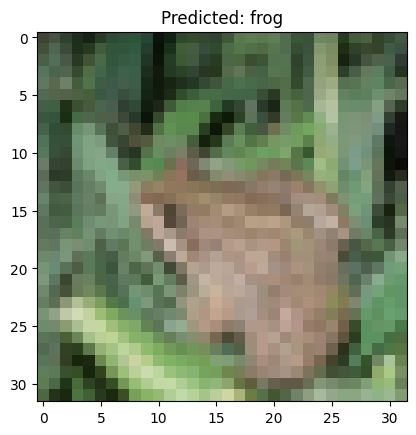

In [14]:
preds=model.predict(x_test[:5])
for i, pred in enumerate(preds):
  plt.imshow(x_test[i])
  plt.title(f'Predicted: {class_names[np.argmax(pred)]}')
  plt.show()